In [1]:
import sys
sys.path.append('/home/ec2-user/SEAJ-TEAM-4-')
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np


In [2]:
from backend.python.data_processing.constants import DEFAULT_TICKERS
from backend.python.data_analysis.loader import MarketDataLoader
from backend.python.data_analysis.cleaner import MarketDataCleaner
from backend.python.data_analysis.features import MarketFeatureEngineer

loader = MarketDataLoader()
raw_df = loader.load_analysis_data(DEFAULT_TICKERS)

print("Raw Shape:", raw_df.shape)
clean_df = MarketDataCleaner.clean(raw_df)
df = MarketFeatureEngineer.add_all_features(clean_df)
print("Cleaned and Engineered Shape:", df.shape)


2026-09-15 08:23:18,333 - INFO - Starting data load for 47 tickers
2026-09-15 08:23:18,334 - INFO - Downloading batch 1 with 47 tickers
2026-09-15 08:23:18,335 - INFO - Downloading historical data for 47 instruments from 2016-01-01 to None
2026-09-15 08:23:22,402 - INFO - Successfully downloaded data for batch of 47 tickers
2026-09-15 08:23:22,689 - INFO - Converted to long format: 126383 records, 7 columns
2026-09-15 08:23:22,692 - INFO - Successfully downloaded data for 126383 records across all batches
2026-09-15 08:25:32,487 - ERROR - Failed to load instrument metadata: connection to server at "10.9.69.224", port 5432 failed: Connection timed out
	Is the server running on that host and accepting TCP/IP connections?

2026-09-15 08:25:32,489 - WARNING - No metadata retrieved from PostgreSQL, returning market data only
2026-09-15 08:25:32,490 - INFO - Starting data cleaning pipeline: 126383 records input
2026-09-15 08:25:32,526 - WARNING - Found 1 rows with invalid volumes (volume <= 

Raw Shape: (126383, 7)


2026-09-15 08:25:32,748 - INFO - Calculated daily_return for all symbols
2026-09-15 08:25:32,766 - INFO - Calculated cumulative_return for all symbols
2026-09-15 08:25:32,857 - INFO - Calculated log_return for all symbols
2026-09-15 08:25:32,917 - INFO - Calculated rolling_volatility (window=30) for all symbols
2026-09-15 08:25:32,943 - INFO - Calculated drawdown for all symbols
2026-09-15 08:25:32,958 - INFO - Calculated price_range for all symbols
2026-09-15 08:25:33,010 - INFO - Calculated volume_ma (window=20) for all symbols
2026-09-15 08:25:33,011 - INFO - Feature engineering complete: 14 columns, 126358 rows


Cleaned and Engineered Shape: (126358, 14)


## Price Summary

In [3]:
price_summary = df[["open", "high", "low", "close"]].describe().T
price_summary


,count,mean,std,min,25%,50%,75%,max
open,126358.0,176.344890,167.373881,0.603037,62.611637,119.189496,235.353591,1274.130005
high,126358.0,177.974332,168.988772,0.622019,62.981634,120.250193,237.827620,1292.650024
low,126358.0,174.668506,165.678588,0.602307,62.251719,118.103968,232.987896,1243.229980
close,126358.0,176.359486,167.356514,0.613745,62.608525,119.279297,235.437061,1280.339966


## Distribution of closing prices 

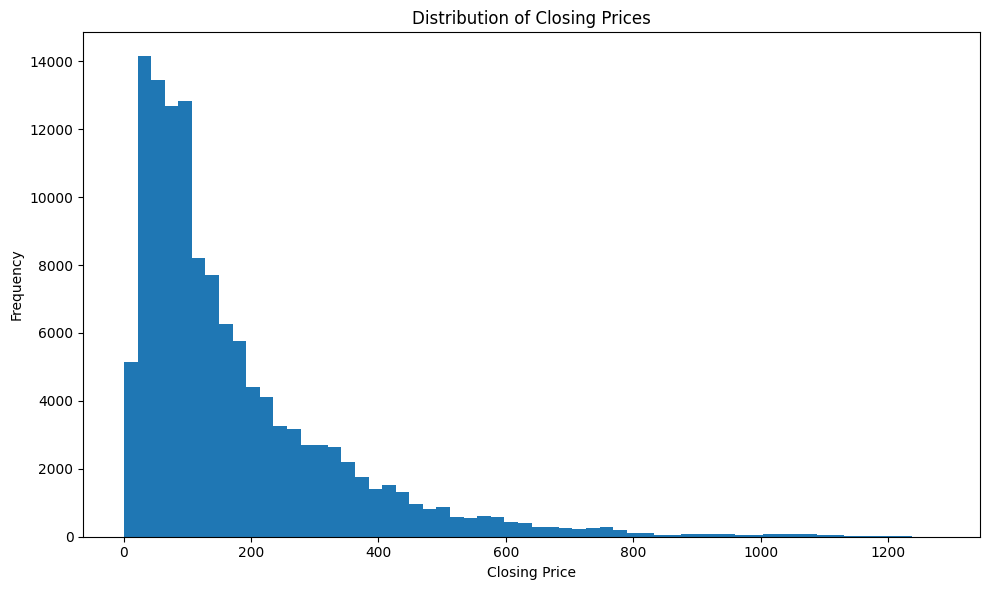

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["close"].dropna(), bins=60)
ax.set_title("Distribution of Closing Prices")
ax.set_xlabel("Closing Price")
ax.set_ylabel("Frequency")

fig.tight_layout()
plt.show()

## Closing price distribution by asset class

In [7]:
df.columns.tolist()
metadata = loader.load_instrument_metadata()
metadata.head()
metadata.shape

2026-09-15 08:29:48,487 - ERROR - Failed to load instrument metadata: connection to server at "10.9.69.224", port 5432 failed: Connection timed out
	Is the server running on that host and accepting TCP/IP connections?



(0, 0)

In [ ]:
# need db connection to run

asset_class = df["asset_class"].dropna().unique().tolist()
fig, ax = plt.subplots(figsize=(10, 6))

data= [
    df.loc[df["asset_class"] == asset_class, "close"].dropna()
    for asset_class in asset_class
]

ax.boxplot(data, labels=asset_class)
ax.set_title("Distribution of Closing Prices by Asset Class")
ax.set_xlabel("Asset Class")
ax.set_ylabel("Closing Price")
fig.tight_layout()
plt.show()

KeyError: 'asset_class'

## Volume Summary

In [6]:
volume_summary = (
    df.groupby(["symbol", "name", "asset_class"], dropna=False)
    .agg(
        mean_volume=("volume", "mean"),
        median_volume=("volume", "median"),
        max_volume=("volume", "max")
    )
    .reset_index()
    .sort_values(by="median_volume", ascending=False)
)

volume_summary.head()

KeyError: 'name'

In [8]:
top_volume = volume_summary.head(10).sort_values("median_volume")
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_volume["symbol"], top_volume["median_volume"])

ax.set_title("Top 10 Symbols by Median Volume")
ax.set_xlabel("Median Volume")
ax.set_ylabel("Symbol")

plt.show()

NameError: name 'volume_summary' is not defined

## Normalised Price

In [9]:
normalised_start = (
    df.sort_values(["symbol", "date"])
    .groupby("symbol", as_index=False)
    .first()[["symbol", "normalised_price"]]
)

KeyError: "['normalised_price'] not in index"

KeyError: 'normalised_price'

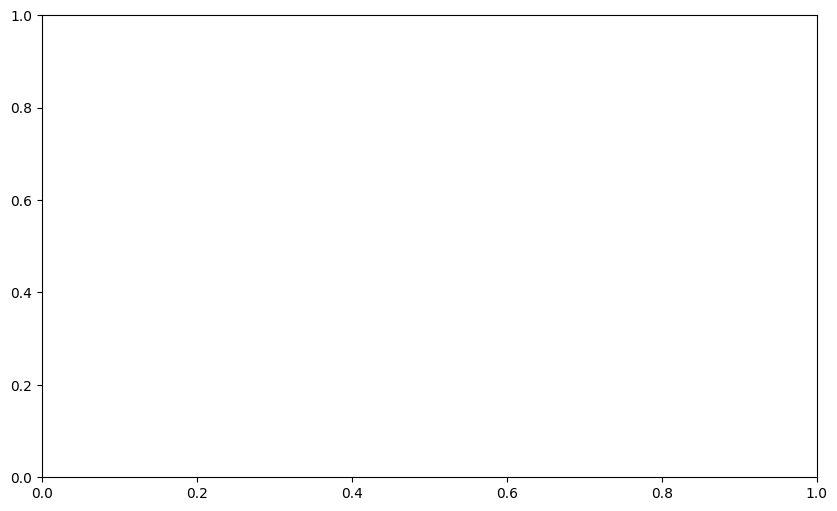

In [10]:
selected_symbols = (
    df["symbol"].drop_duplicates().head(8).tolist()
)

fig, ax = plt.subplots(figsize=(10, 6))
for symbol in selected_symbols:
    subset = df[df["symbol"] == symbol]
    ax.plot(subset["date"], subset["normalised_price"], label=symbol)
      
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.set_title("Normalised Price Over Time for Selected Symbols")
ax.legend()
plt.show()